Retail Sales Analysis and Sales Prediction using Machine Learning

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
print("All Libraries are imported successfully")

All Libraries are imported successfully


In [7]:
from google.colab import files

uploaded = files.upload()
print("file uploaded successfully!")

Saving Superstore_Sales_Dataset.csv to Superstore_Sales_Dataset (2).csv
file uploaded successfully!


In [9]:
df = pd.read_csv("Superstore_Sales_Dataset.csv")


In [10]:
df.head()

,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Segment,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Ship Mode
0,ORD1002,2025-10-12,2025-10-15,C799,Rohan,Home Office,South,Furniture,Tables,Tables Model 181,230.62,2,0.1,42.86,Second Class
1,ORD1003,2025-12-24,2025-12-28,C917,Neha,Home Office,South,Office Supplies,Storage,Storage Model 803,871.10,3,0.1,203.31,Standard Class
2,ORD1004,2025-07-20,2025-07-21,C830,Ananya,Consumer,North,Technology,Phones,Phones Model 711,141.07,6,0.0,37.04,Standard Class
3,ORD1005,2025-06-30,2025-07-01,C227,Mahi,Home Office,East,Furniture,Bookcases,Bookcases Model 579,1329.65,10,0.0,451.20,First Class
4,ORD1006,2025-07-26,2025-07-30,C699,Ananya,Home Office,South,Furniture,Tables,Tables Model 403,879.40,7,0.0,227.40,Second Class


In [11]:
df.tail()

,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Segment,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Ship Mode
195,ORD1197,2025-02-06,2025-02-08,C373,Neha,Home Office,West,Technology,Phones,Phones Model 171,1180.14,9,0.3,165.26,First Class
196,ORD1198,2025-04-23,2025-04-29,C826,Sneha,Corporate,East,Office Supplies,Storage,Storage Model 225,1601.32,2,0.3,255.19,Same Day
197,ORD1199,2025-04-24,2025-04-25,C233,Rahul,Corporate,South,Technology,Copiers,Copiers Model 329,1626.01,1,0.0,479.28,Second Class
198,ORD1200,2025-01-12,2025-01-15,C829,Neha,Consumer,East,Technology,Phones,Phones Model 178,286.45,4,0.2,56.20,Same Day
199,ORD1201,2025-08-25,2025-08-30,C841,Mahi,Consumer,West,Office Supplies,Storage,Storage Model 401,1833.64,4,0.3,-153.65,Second Class


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       200 non-null    object 
 1   Order Date     200 non-null    object 
 2   Ship Date      200 non-null    object 
 3   Customer ID    200 non-null    object 
 4   Customer Name  200 non-null    object 
 5   Segment        200 non-null    object 
 6   Region         200 non-null    object 
 7   Category       200 non-null    object 
 8   Sub-Category   200 non-null    object 
 9   Product Name   200 non-null    object 
 10  Sales          200 non-null    float64
 11  Quantity       200 non-null    int64  
 12  Discount       200 non-null    float64
 13  Profit         200 non-null    float64
 14  Ship Mode      200 non-null    object 
dtypes: float64(3), int64(1), object(11)
memory usage: 23.6+ KB


In [13]:
df.describe()

,Sales,Quantity,Discount,Profit
count,200.00000,200.000000,200.000000,200.000000
mean,977.01260,5.315000,0.155500,105.922400
std,585.74833,2.889206,0.115483,132.535835
min,27.39000,1.000000,0.000000,-177.480000
25%,430.17750,3.000000,0.075000,21.215000
50%,952.66500,5.000000,0.200000,58.925000
75%,1485.29750,8.000000,0.300000,181.490000
max,1995.91000,10.000000,0.300000,536.180000


In [14]:
df.shape

(200, 15)

In [15]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Customer ID,0
Customer Name,0
Segment,0
Region,0
Category,0
Sub-Category,0
Product Name,0


In [16]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1869/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [19]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [20]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [21]:
df["Month"] = df["Order Date"].dt.month

In [22]:
df["Year"] = df["Order Date"].dt.year

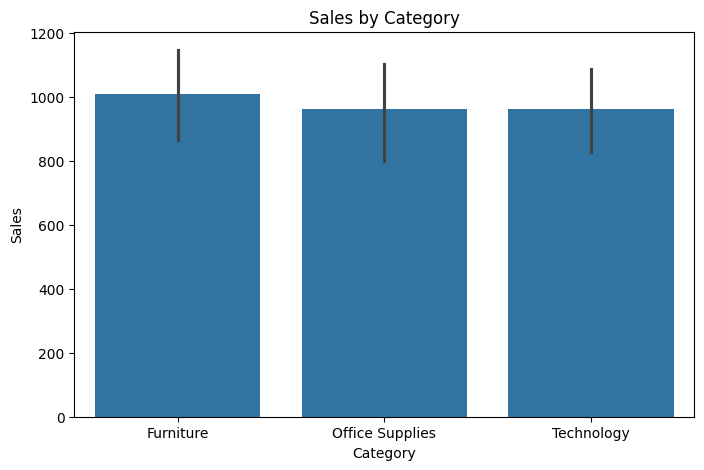

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category',y='Sales',data=df)
plt.title("Sales by Category")
plt.show()

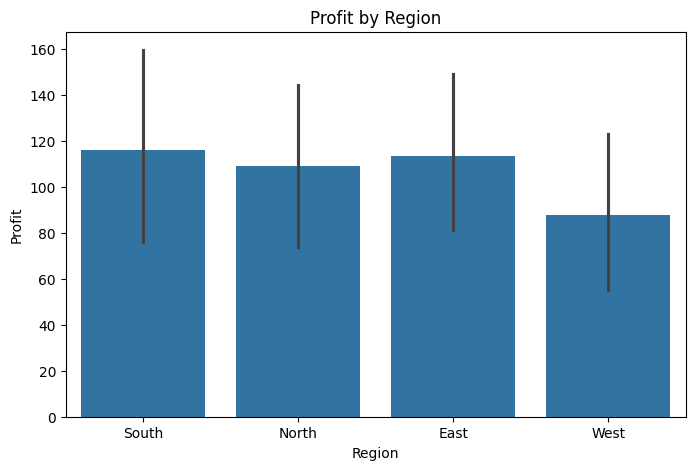

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region',y='Profit',data=df)
plt.title("Profit by Region")
plt.show()

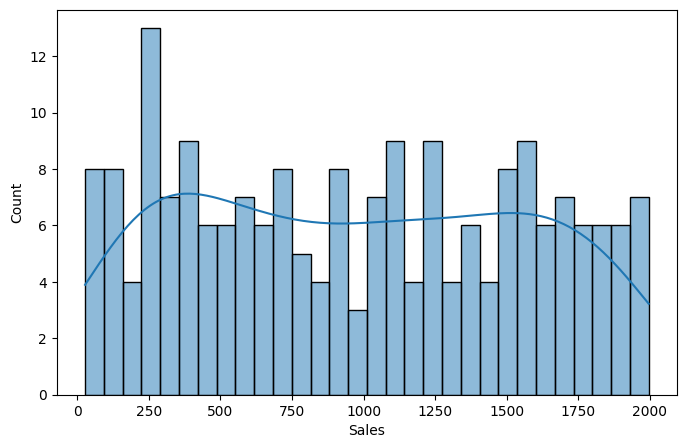

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'],bins=30,kde=True)
plt.show()

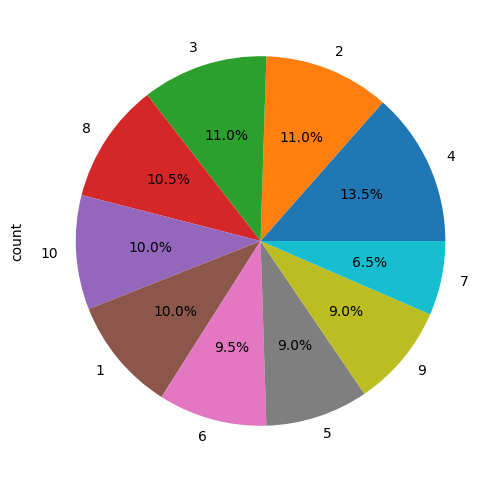

In [26]:
plt.figure(figsize=(6,6))
df["Quantity"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.show()

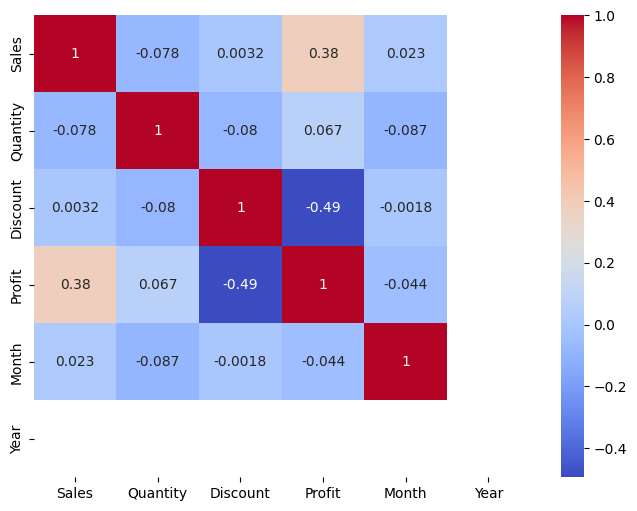

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

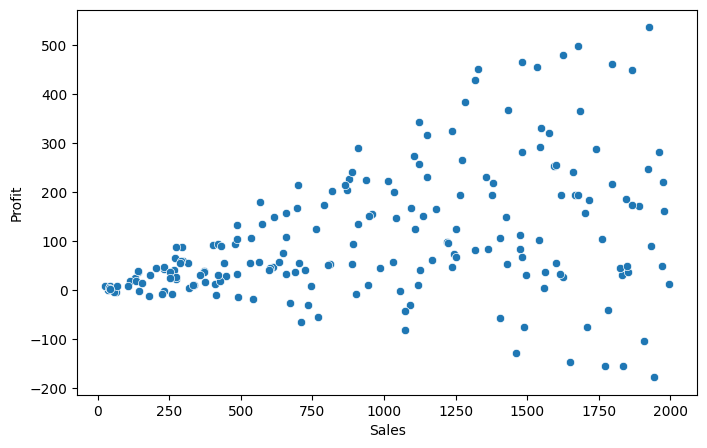

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Sales",y="Profit",data=df)
plt.show()

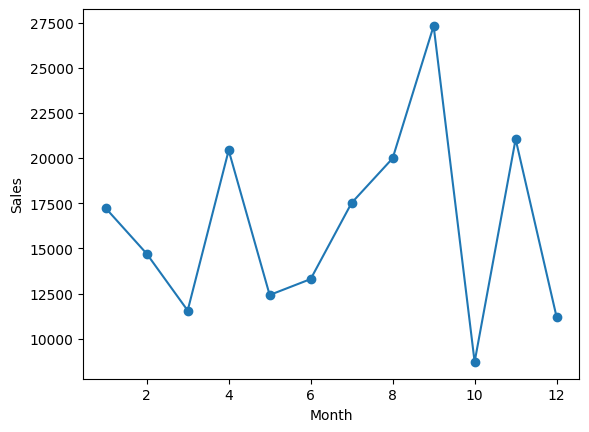

In [29]:
monthly=df.groupby("Month")["Sales"].sum()

monthly.plot(kind="line",marker="o")
plt.ylabel("Sales")
plt.show()

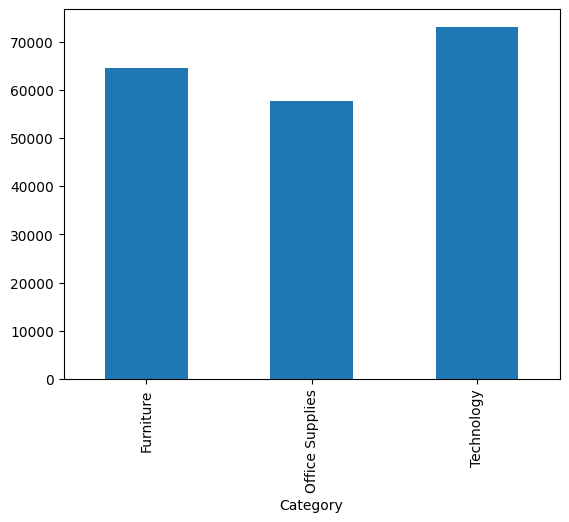

In [30]:
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.show()

In [31]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

columns=['Category','Region','Segment','Ship Mode','Sub-Category']

for col in columns:
    df[col]=le.fit_transform(df[col])

In [32]:
X=df[['Category',
      'Quantity',
      'Discount',
      'Region',
      'Segment',
      'Month']]

y=df['Sales']

In [33]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
model=RandomForestRegressor(random_state=42)

model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [35]:
prediction=model.predict(X_test)

In [36]:
print("R2 Score :",r2_score(y_test,prediction))

R2 Score : -0.17966642814887468


In [37]:
print("RMSE :",np.sqrt(mean_squared_error(y_test,prediction)))

RMSE : 618.4460604042615


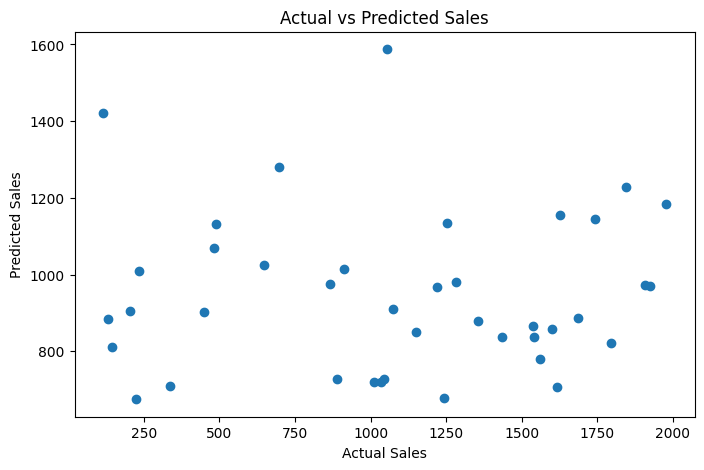

In [38]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,prediction)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

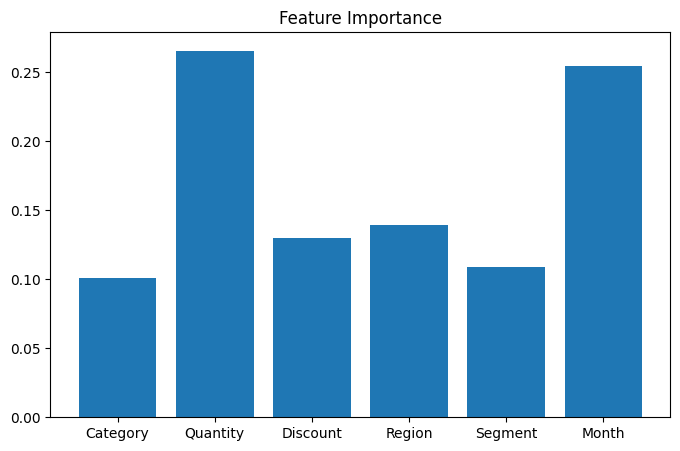

In [39]:
importance=model.feature_importances_

features=X.columns

plt.figure(figsize=(8,5))

plt.bar(features,importance)

plt.title("Feature Importance")

plt.show()

## Conclusion

- Technology products generated the highest sales.
- Higher discounts generally reduced profits.
- Sales varied across different regions.
- Monthly sales showed seasonal patterns.
- The Random Forest model achieved good prediction performance.
- This project demonstrates end-to-end data analysis and machine learning using a real-world retail dataset.